# spectra_multi_atom; HI, HeI and CaII 

- 2023.07.20   k.u,  k.i.. 

In [1]:
from IPython.core.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
%load_ext autoreload
%autoreload 2

from spectra.ImportAll import *
import warnings
warnings.simplefilter('ignore', UserWarning)
warnings.simplefilter('ignore', DeprecationWarning)

C:\Users\ichim\AppData\Local\Temp\ipykernel_9596\2770024011.py:1: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display, HTML


In [3]:
from spectra.Struct import Atom, Atmosphere, Radiation
from spectra.Atomic import Collision, SEsolver, ContinuumOpacity, BasicP
from spectra.Util.HelpUtil import help_
from spectra.Visual import Plotting  #, Grotrian
from spectra.Atomic import LTELib
from spectra.Function.SEquil import SELib
from spectra.Atomic import Hydrogen
from spectra.Util.AtomUtils.AtomInfo import level_info, extract_lprof, each_prof, line_list
from spectra import Constants as Cst
from spectra.Function.SlabModel import CloudModel


## Create atomic model for H, He, Ca

In [4]:
# Atomic model
import os

conf_path = os.path.join( CFG._ROOT_DIR, "data/conf/H.conf" )  ; H_nam ='H'
atom_H, wMesh_H, path_dict_H = Atom.init_Atom_(conf_path , is_hydrogen=True)
conf_path = os.path.join( CFG._ROOT_DIR, "data/conf/He.conf" ) ; He_nam ='He'
atom_He, wMesh_He, path_dict_He = Atom.init_Atom_(conf_path , is_hydrogen=False)
conf_path = os.path.join( CFG._ROOT_DIR, "data/conf/Ca_II.conf" ) ; Ca_nam ='Ca_II'
atom_Ca, wMesh_Ca, path_dict_ca = Atom.init_Atom_(conf_path , is_hydrogen=False)


## Make Solar spectrum array

wleuv= 5.04e-06


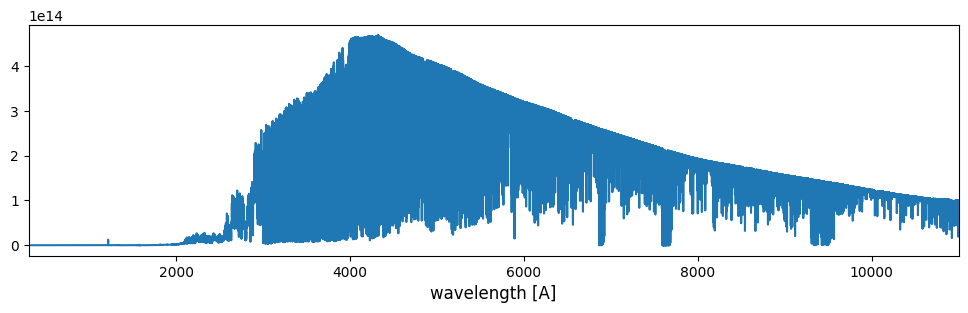

In [8]:
#  prepare solar radiation spectrum
import copy

atmos = Atmosphere.Atmosphere0D(Nh=1.E12, Ne=1.E11, Te=7.E3, Vd=0., Vt=5.E5)
solar_spec_H  = Radiation.init_Radiation_()
solar_spec_He = Radiation.init_Radiation_()
solar_spec_Ca = Radiation.init_Radiation_()

wls = solar_spec_H.solar[0,:]*1E8         
wls_air = BasicP.vacuum_to_air_(wls,'AA')   # wavelength in air of background solar spectrum [A]
Isolar = solar_spec_H.solar[1,:].copy()   # background solar spectrum intensity    "    [erg/cm^3/s/str]

#  for photo-excitation, mean intensity gets half of the backgroud solar spectrum
#  (issue#6 refactor: solar drives both line Jbar and continuum PI; one scaling covers both)
solar_spec_H.solar[1,:]  *= 0.5            # solar spectrum mean intensity    "    [erg/cm^3/s/str]
solar_spec_He.solar[1,:] *= 0.5            # solar spectrum mean intensity    "    [erg/cm^3/s/str]
solar_spec_Ca.solar[1,:] *= 0.5            # solar spectrum mean intensity    "    [erg/cm^3/s/str]

EUV_ampl = 5   # EUV enhancement for He background
solar_spec_He = enhance_EUV(solar_spec_He,wMesh_He,EUV_ampl)

fig, ax = plt.subplots(1,1, figsize=(12,3), dpi=100)
ax.plot(wls_air, Isolar)
ax.set_xlim(300, 11000)
ax.set_xlabel("wavelength [A]", fontsize=12)
plt.show()

## Calc. SE and line profiles for H, He, Ca for a [$T_e,n_H$]

In [9]:
def enhance_EUV(solar_spec,wMesh,ampl,wleuv=504.):  # Enhance EUV for He 1083nm
    
    # amp_euv = 10.  #  enhance EUV radiation for He 10830

    solar_spec2 = copy.deepcopy(solar_spec)
    wleuv *= 1e-8
    print("wleuv=",wleuv)

    # issue#6 refactor: solar drives both line Jbar and continuum PI rates,
    # so one scaling on `solar` covers what previously needed paired backRad/PI_intensity edits.
    # The old `PI_intensity.reshape(-1)[ii]` line was a pre-existing index-mismatch bug
    # (ii sized to backRad atlas, not PI_intensity); dropping it.
    ii = np.where(solar_spec2.solar[0,:] < wleuv)[0]
    solar_spec2.solar[1,ii] *= ampl
    
    return solar_spec2
    

In [10]:
# import CloudModel from spectra.Function.SlabModel

Te = 8000.
Nh = 1*1e11
Ne = 2e10
Vd = 0.
Vt = 5e5            #   cm/s
depth = 0.5E4 * 1.E5 #   km *1e5

slab = Atmosphere.Atmosphere0D(Nh=Nh, Ne=Ne, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
SE_H, Rate_H = SELib.cal_SE_with_Nh_Te_(atom_H, slab, wMesh_H, solar_spec_H, None)  #  level populations etc.
lH = CloudModel.SE_to_slab_0D_(atom_H, slab, SE_H, depth=depth)      # hydrogen lines intensity
SE_He, Rate_He = SELib.cal_SE_with_Nh_Te_(atom_He, slab, wMesh_He, solar_spec_He, SE_H.n_SE)  #  level populations etc.
lHe = CloudModel.SE_to_slab_0D_(atom_He, slab, SE_He, depth=depth)      # hydrogen lines intensity
SE_Ca, Rate_Ca = SELib.cal_SE_with_Nh_Te_(atom_Ca, slab, wMesh_Ca, solar_spec_Ca, SE_H.n_SE)  #  level populations etc.
lCa = CloudModel.SE_to_slab_0D_(atom_Ca, slab, SE_Ca, depth=depth)      # hydrogen lines intensity


## Plot H, He, CaII emissions w/ a prominence spectrum

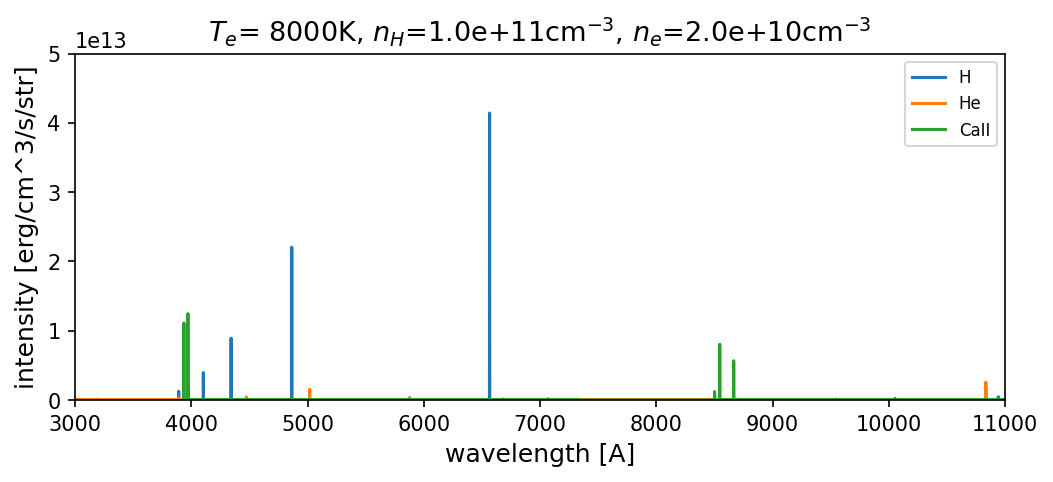

In [11]:
fig, ax = plt.subplots(1,1, figsize=(8,3), dpi=150)
ax.plot(lH.wl_1D*1e8,lH.prof_1D,label='H')
ax.plot(lHe.wl_1D*1e8,lHe.prof_1D,label='He')
ax.plot(lCa.wl_1D*1e8,lCa.prof_1D,label='CaII')
ax.set_ylim(1e9,1E14)
#ax.set_xlim(300, 12000)
#ax.set_xscale("log")
ax.set_xlim(3000, 11000)
#ax.set_yscale("log")
ax.set_ylim(0, 5e13)
ax.set_xlabel("wavelength [A]", fontsize=12)
ax.set_ylabel("intensity [erg/cm^3/s/str]", fontsize=12)
plt.title("$T_e$={0:5.0f}K, $n_H$={1:5.1e}cm$^{{-3}}$, $n_e$={2:5.1e}cm$^{{-3}}$".format(Te, Nh, Ne),fontsize=13)
ax.legend(fontsize=8,ncol=1)
plt.show()

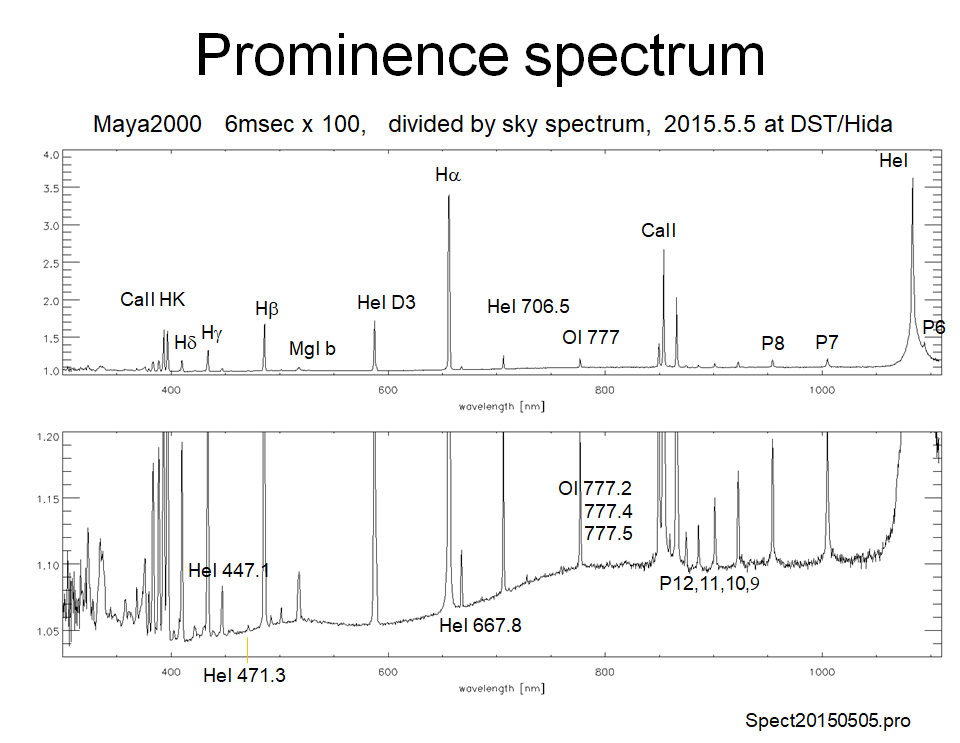

# Extract lines of interest 
## plot intensity profile from a slab with a continuum background

### cloud model: $\qquad$    $I_{out} = I_{c} e^{-\tau} + S (1-e^{-\tau})$

In [12]:
#-------------------------------------------------------------
def extract_line(l, wl, Ic=0.):
#-------------------------------------------------------------
# extract line profile in a wl interval from l-structure
# wl[:]  -- in A 
# Ic  -- background intensity

    nw = wl.size
    profe = np.zeros(nw)
    tau = np.zeros(nw)

    w0 = l.w0 *1e8
    jj = np.where((w0 > min(wl)) & (w0 < max(wl)))[0]

    for j in jj:
        idx1 = l.Line_mesh_idxs[j,0] 
        idx2 = l.Line_mesh_idxs[j,1]
        tau1 = np.interp(wl, l.wl_1D[idx1:idx2]*1e8, l.tau_1D[idx1:idx2])
        prof1 = l.Src[j] * (1.-np.exp(-tau1))
        #print('Ic, Src=',Ic,l.Src[j])
        tau += tau1
        profe += prof1
        
    prof = Ic*np.exp(-tau) + profe
    
    ldat = {
        "intens": prof,
        "tau": tau,
        "src": max(l.Src[jj]),
    }
    
    return ldat


In [13]:
def wlarr(wl00,vmax,dv):
# return wl[:] around wl00 in A,  vmax, dv  in km/s

    dw = dv/Cst.c_*wl00*1e5
    wmin = wl00 - dw*vmax/dv
    wmax = wl00 + dw*vmax/dv
    nw = 2*int(vmax/dv) +1
    #nw = int((wmax-wmin)/dw) + 1
    wl = np.linspace(wmin,wmax,nw)
    return wl


dict_keys(['elem', 'wl0', 'wl', 'wl_air', 'Isolar', 'Ic'])
dict_keys(['elem', 'wl0', 'wl', 'wl_air', 'Isolar', 'Ic'])
dict_keys(['elem', 'wl0', 'wl', 'wl_air', 'Isolar', 'Ic'])


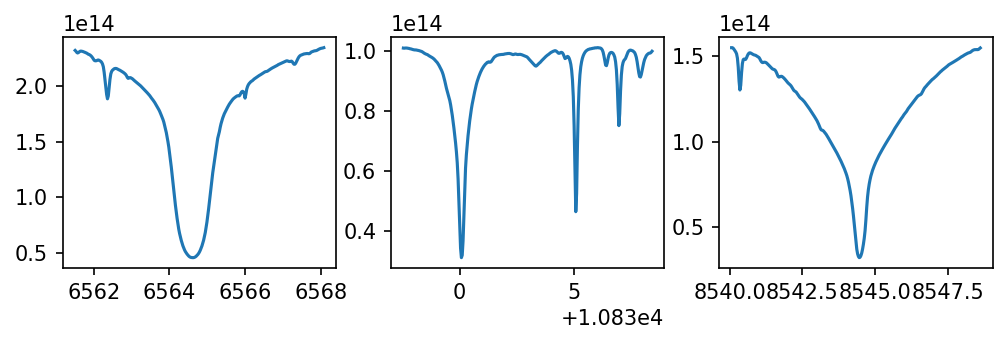

In [14]:
### define lines of interest ###

vmax = 150. ; dv = 1.  # km/s

ls = [
    {'elem': 'H',  'wl0': 6563.},
    {'elem': 'He', 'wl0': 10830.},
    {'elem':'Ca',  'wl0': 8542.}
    #{'elem':'Ca',  'wl0': 3934.}
]

nl = len(ls)
for i in range(nl):
    wl_air = wlarr( ls[i]['wl0'], vmax, dv )  # w-array in air centered by the line
    wl = BasicP.air_to_vacuum_(wl_air,'AA') # w-array in vacuum
    Isol = np.interp(wl, wls, Isolar)        # Solar spectrum of the line
    Ic = np.max(Isol)                         # continuum intensity
    ls[i].update({'wl': wl, 'wl_air': wl_air, 'Isolar': Isol, 'Ic': Ic})
    print(ls[i].keys())

### plot a line profile in solar spectrum ###
fig, axs = plt.subplots(1,nl, figsize=(8,2), dpi=150)
for i in range(nl):
    axs[i].plot(ls[i]['wl'],ls[i]['Isolar'])
    ax.set_ylim(0,max(ls[i]["Isolar"])*1.2)


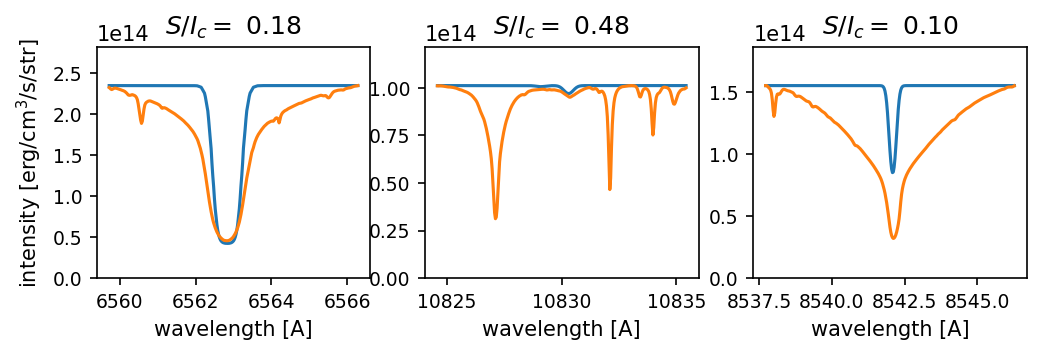

In [15]:
##  plot line profiles with background continuum

fig, axs = plt.subplots(1,nl, figsize=(8,2), dpi=150)

for i in range(nl):
    if ls[i]['elem'] == 'H':
        l_elm = lH
    elif ls[i]['elem'] == 'He':
        l_elm = lHe
    elif ls[i]['elem'] =='Ca':
        l_elm = lCa
    l1 = extract_line(l_elm, ls[i]['wl'], Ic=ls[i]['Ic'])   #  ['intens', 'tau', 'src']
    ls[i].update(l1)
    ax = axs[i]
    ax.plot(ls[i]['wl_air'], ls[i]['intens'])
    ax.plot(ls[i]['wl_air'], ls[i]['Isolar'])
    ax.set_xlabel("wavelength [A]", fontsize=10)
    ax.tick_params(axis ='x', labelsize =9)
    ax.tick_params(axis ='y', labelsize =9)
    if i == 0:
        ax.set_ylabel("intensity [erg/cm$^3$/s/str]", fontsize=10)
    ax.set_ylim(0,max(ls[i]["intens"])*1.2)
    ax.set_title(r"$S/I_c=$"+f"{ls[i]['src']/ls[i]['Ic']:5.2F}")


## Display level population and transition rates

In [16]:
##  method to access to Level info.
atom = atom_Ca
print('level stage',atom.Level['stage'])
print('level energy',atom.Level['erg'])
print('config. term, j',atom._ctj_table.Level[3])     
int(atom._ctj_table.Level[3][1][0]) == 3          # level#=3, 1=term,  '3'

level stage [2 2 2 2 2 3]
level energy [0.00000000e+00 2.71153653e-12 2.72359131e-12 5.00415674e-12
 5.04843289e-12 1.90205906e-11]
config. term, j ('1s2.2s2.2p6.3s2.3p6.4p', '2P', '1/2')


False

## Display level population and transition rates

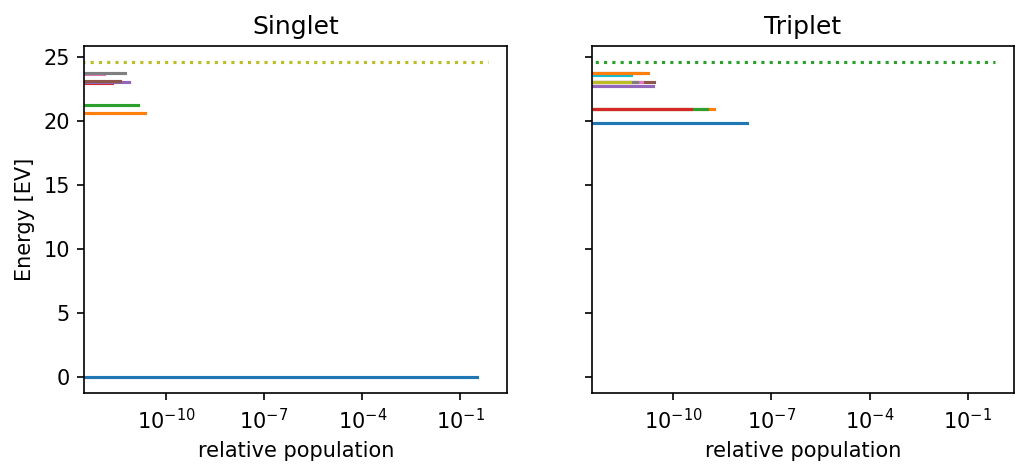

In [17]:
##  plot He level populations  ####################################################

atom = atom_He
SE = SE_He
mask = atom.Level['stage'] == 1           # select neutoral
ilevel_heii = np.where(atom.Level['stage'] == 2)[0][0]      # HeI ionization = groud state of HeII

level_erg = atom.Level['erg'][mask]
level_erg = np.append( level_erg, atom.Level['erg'][ilevel_heii] )
level_ev  = level_erg / Cst.eV2erg_
level_energy = level_ev

level_pop = SE.n_SE[mask]
level_pop = np.append( level_pop,  SE.n_SE[np.logical_not(mask)].sum())

fig, axs = plt.subplots(1,2, figsize=[8,3], dpi=150, sharey=True, sharex=True)

#axt = axs.twinx()
for i in range(level_erg.shape[0]):
    s2p1 = int(atom._ctj_table.Level[i][1][0])   #  1 - HeI singlet, 2 - HeII or 3 - HeI triplet
    if s2p1 == 1:
        axs[0].set_title('Singlet')
        axs[0].plot([0,level_pop[i]],level_energy[i]*np.ones(2))
    elif s2p1 == 3:
        axs[1].set_title('Triplet')
        axs[1].plot([0,level_pop[i]],level_energy[i]*np.ones(2))
    elif s2p1 == 2:
        axs[0].plot([0,level_pop[i]],level_energy[i]*np.ones(2),':')
        axs[1].plot([0,level_pop[i]],level_energy[i]*np.ones(2),':')        
    else:
        continue
    #print(i, level_pop[i])
    
for ax in axs:
    ax.set_xscale('log')
    ax.set_xlabel('relative population')
axs[0].set_ylabel('Energy [EV]')
#ax.plot(level_erg,level_pop,'o')
#ax.barh(level_erg,level_pop, align='center')
#level_erg
plt.show()

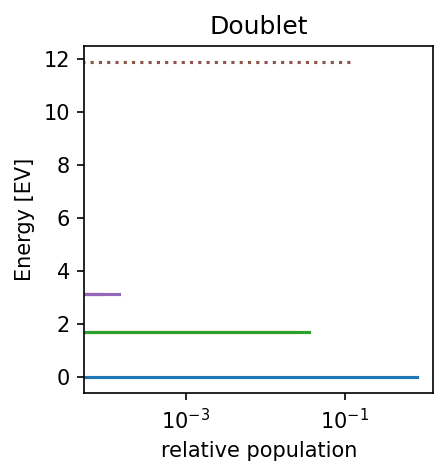

In [18]:
##  plot Ca level populations  ####################################################

atom = atom_Ca   
SE = SE_Ca
mask = atom.Level['stage'] == 2           # select neutoral
ilevel_caiii = np.where(atom.Level['stage'] == 3)[0][0]      # HeI ionization = groud state of HeII

level_erg = atom.Level['erg'][mask]
level_erg = np.append( level_erg, atom.Level['erg'][ilevel_caiii] )
level_ev  = level_erg / Cst.eV2erg_
level_energy = level_ev

level_pop = SE.n_SE[mask]
level_pop = np.append( level_pop,  SE.n_SE[np.logical_not(mask)].sum())

fig, ax = plt.subplots(1,1, figsize=[3,3], dpi=150, sharey=True, sharex=True)

#axt = axs.twinx()
for i in range(level_erg.shape[0]):
    s2p1 = int(atom._ctj_table.Level[i][1][0])   #  1 - HeI singlet, 2 - HeII or 3 - HeI triplet
    if s2p1 == 2:
        ax.set_title('Doublet')
        ax.plot([0,level_pop[i]],level_energy[i]*np.ones(2))
    elif s2p1 == 1:
        ax.plot([0,level_pop[i]],level_energy[i]*np.ones(2),':')
    else:
        continue
    #print(i, level_pop[i])
    
ax.set_xscale('log')
ax.set_xlabel('relative population')
ax.set_ylabel('Energy [EV]')
#ax.plot(level_erg,level_pop,'o')
#ax.barh(level_erg,level_pop, align='center')
#level_erg
plt.show()

In [19]:
#------------------------------------------------------------
def transition_heatmap(atom, SE_con, Rate_con, vmin=None, vmax=None, klevel_max=None,cmap='cool',title_prefix='',figsize=(10,6),level_order='energy'):

    #SE_con = SE_He
    #Rate_con = Rate_He
    numeric_error=1E-17
    if klevel_max is None: klevel_max = atom.nLevel
    #klevel_max = 21
    
    if level_order == 'multiplet':    # -- consider only HeI
        ctj_level = atom._ctj_table.Level
        idx_singlet = []
        idx_triplet = []
        idx_doublet = []    #  He ion 
        s2p1_list = []
        for i in range(klevel_max):
            #print(atom.Level['stage'][i])
            ctj = ctj_level[i]
            s2p1 = ctj[1][0]
            if s2p1 == '1':   # singlet
                idx_singlet.append(i)
            elif s2p1 == '3':
                idx_triplet.append(i)
            elif s2p1 == '2':
                idx_doublet.append(i)
            else:
                continue
        idx_sort = idx_singlet + idx_triplet + idx_doublet
        #icont = np.where( (atom.Level['stage']==2) * (atom.Level['isGround']==1) )[0][0]
        #print(f"idx of continuum is {icont}")
        #idx_sort.append(icont)
        n_SE = SE_con.n_SE[idx_sort]
        Rmat = Rate_con.Rmat[idx_sort,:][:,idx_sort]
        Cmat = Rate_con.Cmat[idx_sort,:][:,idx_sort]
        n_SE = SE_con.n_SE[idx_sort].reshape(1,-1)
        ctj_level = [ctj_level[i] for i in idx_sort]
        ctjs = [f"{ctj[1]} {ctj[2]}" for ctj in ctj_level[:klevel_max]]
    else:
        Rmat = Rate_con.Rmat[:klevel_max,:klevel_max]
        Cmat = Rate_con.Cmat[:klevel_max,:klevel_max]
        n_SE = SE_con.n_SE[:klevel_max].reshape(1,-1)
        ctjs = [f"{ctj[1]} {ctj[2]}" for ctj in atom._ctj_table.Level[:klevel_max]]

    tran_mat = {
        "Radiative" : Rmat * n_SE,
        "Collision" : Cmat * n_SE,
    }

    #if vmin is None: vmin = min( [mat.min() for mat in tran_mat.values()] )
    #if vmax is None: vmax = max( [mat.max() for mat in tran_mat.values()] )
    if vmin is None: vmin = 1e-6
    if vmax is None: vmax = 1e-2
    norm = LogNorm(vmin, vmax, clip=True)

    fig, axs = plt.subplots(1,2, figsize=figsize, dpi=100, sharey=True)
    
    for ax, name in zip( axs, ("Radiative", "Collision") ):
        im = ax.imshow( tran_mat[name] + numeric_error, origin="lower", cmap=cmap, norm=norm )
        if name == "Radiative" and title_prefix != '':
            ax.set_title(name+f" | {title_prefix}")
        else:
            ax.set_title(name)
        ax.set_xticks([i for i in range(klevel_max)])
        ax.set_xticklabels(ctjs, rotation=75, fontsize=8)
        ax.set_yticks([i for i in range(klevel_max)])
        ax.set_yticklabels(ctjs, rotation=0, fontsize=8)


    # colorbar
    cax = fig.add_axes([0.93, 0.2, 0.02, 0.6])
    fig.colorbar( im, cax=cax, orientation='vertical')

    plt.show()
    return None



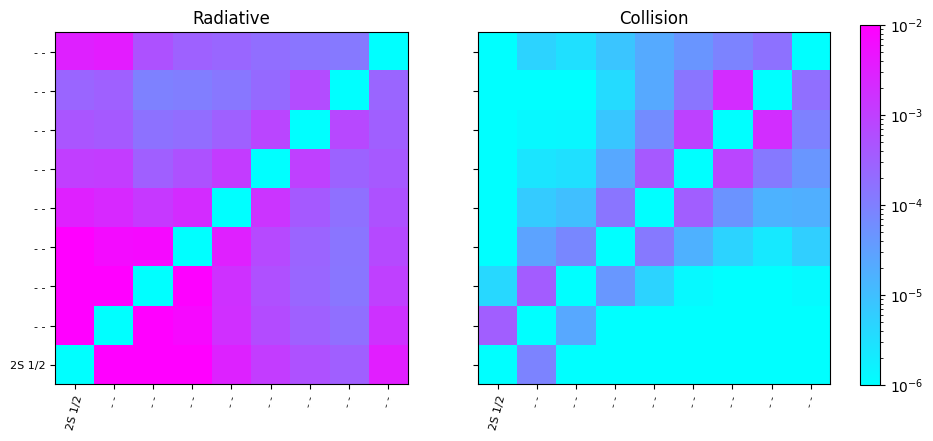

In [20]:
# Transition rale  H
transition_heatmap(atom_H, SE_H, Rate_H, vmin=1e-6, vmax=1e-2) #, klevel_max=21, level_order='multiplet')

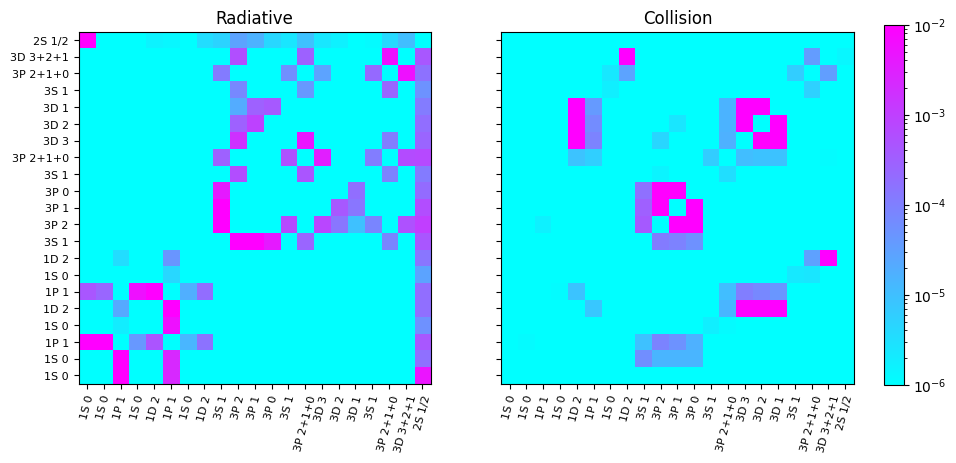

In [21]:
# Transition rale  He
transition_heatmap(atom_He, SE_He, Rate_He, vmin=1e-6, vmax=1e-2, klevel_max=21, level_order='multiplet')

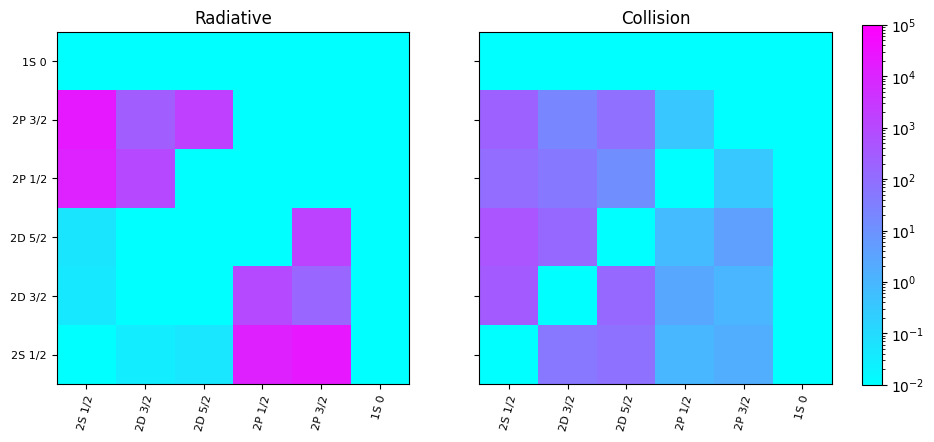

In [22]:
# Ca
#transition_heatmap(atom_Ca, SE_Ca, Rate_Ca,vmin=1e-2,vmax=1e5, klevel_max=31) #, level_order='multiplet')
transition_heatmap(atom_Ca, SE_Ca, Rate_Ca,vmin=1e-2,vmax=1e5)#, klevel_max=31) #, level_order='multiplet')
#help_(atom_Ca)

## Calc. SE and line intensities of HI, HeI, CaII on [$T_e, n_H$] or [$T_e, n_e$] plane 

In [23]:
### result container (dict)including level population & iline intensity etc.
def r_container(atom, N_arr, Te_arr, wl_1D, Line_mesh_idxs, EUV_ampl, depth):
    
    nN = len(N_arr)
    nTe = len(Te_arr)
    nw = len(wl_1D)
    r = {
        "atom"  :   atom,      # atom class
        "EUV_ampl": EUV_ampl,   # EUV enhancement fact
        "depth":    depth,      # depth, cm    
        "N_arr" :   N_arr,                 # density array
        "Te_arr" :  Te_arr,                 # temperature array
        "Nh" :      np.empty((nN, nTe), dtype="float64"),    # Nh array
        "Ne" :      np.empty((nN, nTe), dtype="float64"),    # Ne array
        "pop_LTE" : np.empty((atom.nLevel, nN, nTe), dtype="float64"),  # LTE level population
        "pop_SE"  : np.empty((atom.nLevel, nN, nTe), dtype="float64"),  # SE level population
        "wl0" :    atom.Line['w0_AA'],                # line center wavelengths in A
        "Line_mesh_idxs": Line_mesh_idxs,
        "wl_1D":   wl_1D*1e8,       # 1D wavwlwngth in A
        "prof_3D": np.empty((nw, nN, nTe), dtype="float64"),
        "tau_3D":  np.empty((nw, nN, nTe), dtype="float64"),
        "src" :    np.empty((atom.nLine, nN, nTe), dtype="float64"),
    }
    return r

def calc_popl(slab, depth, atom, wMesh, solar_spec, HnSE, r, j, k, givenN ):

    if givenN == 'Nh':
        SE, Rate = SELib.cal_SE_with_Nh_Te_(atom, slab, wMesh, solar_spec, HnSE)  #  level populations etc.
    elif givenN == 'Ne':
        SE, Rate = SELib.cal_SE_with_Ne_Te_(atom, slab, wMesh, solar_spec, HnSE)  #  level populations etc.
    l = CloudModel.SE_to_slab_0D_(atom, slab, SE, depth=depth)      # hydrogen lines intensity
    r["Nh"][j,k] = slab.Nh
    r["Ne"][j,k] = slab.Ne
    r["pop_LTE"][:,j,k] = SE.n_LTE[:]
    r["pop_SE"][:,j,k] = SE.n_SE[:]
    r["prof_3D"][:,j,k] = l.prof_1D
    r["tau_3D"][:,j,k] = l.tau_1D
    r["src"][:,j,k] = l.Src
    n_SE = SE.n_SE

    return r


In [24]:
#******  calculate populations in SE & LTS on (Te, Nh) or (Te, Ne) ******

nTe = 51 ; Te_arr = np.linspace(2820, 39820, nTe)  # Te=8000
nN = 51 ; N_arr = np.logspace(9, 14, nN)
#Te_arr = np.array([5000.,8000,20000]) ; nTe=len(Te_arr)
#Nh_arr = np.array([1e10,1e11, 1e12]) ; nNh=len(Nh_arr)
Vd = 0.
Vt = 7e5            #   cm/s
depth = 1.E4 * 1.E5 #   km *1e5
givenN = 'Nh'

#***** define name of save files *****
savdir = 'C:\\data\\spectra\\SE_result\\'
H_file = 'HI_'+givenN+'Te.jbl'
He_file = 'HeI_'+givenN+'Te.jbl'
#Ca_file = 'CaI_II_III_'+dens+'Te.jbl'
Ca_file = 'CaII_'+givenN+'Te.jbl'
    
    
slab = Atmosphere.Atmosphere0D(Nh=1e10, Ne=1e9, Te=10000., Vd=Vd, Vt=Vt, use_Tr=False)     # slab 

rH  = r_container(atom_H, N_arr, Te_arr, lH.wl_1D, lH.Line_mesh_idxs, EUV_ampl, depth)
rHe = r_container(atom_He, N_arr, Te_arr, lHe.wl_1D, lHe.Line_mesh_idxs, EUV_ampl, depth)
rCa = r_container(atom_Ca, N_arr, Te_arr, lCa.wl_1D, lCa.Line_mesh_idxs, EUV_ampl, depth)

for j in range(nN):  
    N = N_arr[j]
    for k in range(nTe):
        print(f'\r {j+1}/{nN}, {k+1}/{nTe}', end='\r')
        Te = Te_arr[k]
        slab = Atmosphere.Atmosphere0D(Nh=N, Ne=N, Te=Te, Vd=Vd, Vt=Vt, use_Tr=False)     # slab 
        rH = calc_popl(slab, depth, atom_H, wMesh_H, solar_spec_H, None, rH, j, k, givenN )
        HnSE = rH['pop_SE'][:,j,k]
        rHe = calc_popl(slab, depth, atom_He, wMesh_He, solar_spec_He, HnSE, rHe, j, k, givenN )
        rCa = calc_popl(slab, depth, atom_Ca, wMesh_Ca, solar_spec_Ca, HnSE, rCa, j, k, givenN )
print(f'\r {j+1}/{nN}, {k+1}/{nTe}')


 51/51, 51/51
results rH, rHe, rCa dic saved in 
  C:\data\spectra\SE_result\HI_NhTe.jbl
  C:\data\spectra\SE_result\HeI_NhTe.jbl
  C:\data\spectra\SE_result\CaII_NhTe.jbl


dict_keys(['atom', 'EUV_ampl', 'depth', 'N_arr', 'Te_arr', 'Nh', 'Ne', 'pop_LTE', 'pop_SE', 'wl0', 'Line_mesh_idxs', 'wl_1D', 'prof_3D', 'tau_3D', 'src'])

## Display fraction of HI, HeI, CaII on [$T_e, n_H$] plane

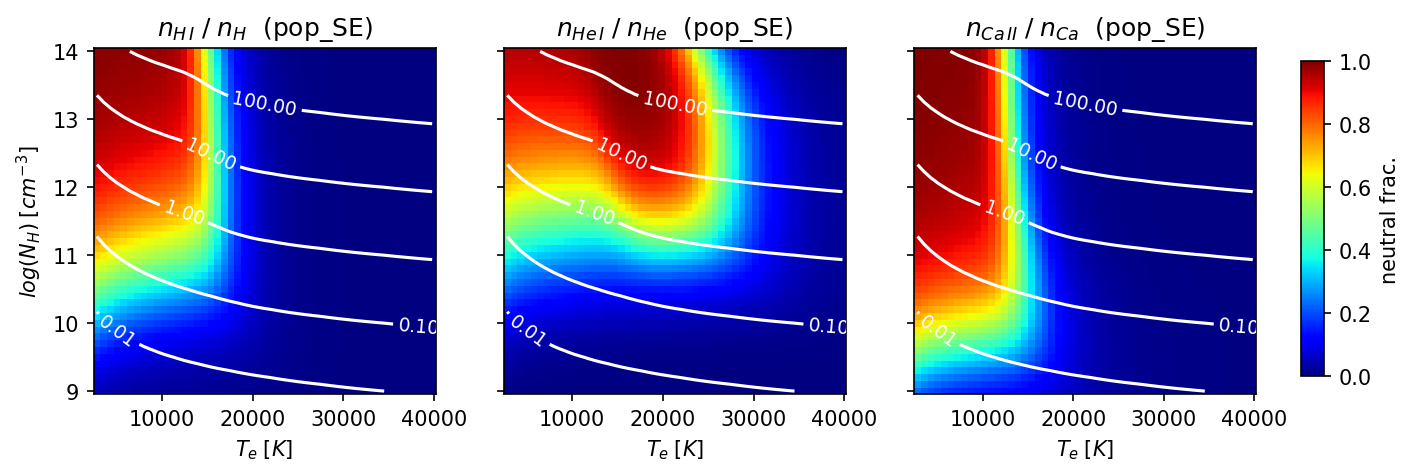

In [26]:
#  display neutral fraction of H and He on (Te, nH) plane
givenN = 'Nh'

#--- sum up neutral populations ---
pop = "pop_SE"
mask_HI = (atom_H.Level['stage'] == 1)
mask_HeI = (atom_He.Level['stage'] == 1)
mask_CaII = (atom_Ca.Level['stage'] == 2)
nHI = np.sum(rH[pop][mask_HI,:,:], axis=0)
nHeI = np.sum(rHe[pop][mask_HeI,:,:], axis=0)
nCaII = np.sum(rCa[pop][mask_CaII,:,:], axis=0)


Te,N = np.meshgrid(Te_arr,np.log10(N_arr))

#if givenN == 'Nh':
#    Ne0      = 1.E-4 * Nh                # [/cm^{3}]
#    Nh = N    # log10(Nh)
#    Ne = Ne0 + 10**Nh * rH[pop][-1,:,:]   # [/cm^{3}]
#    Pg = (10**Nh *1.107 + Ne)*Cst.k_*Te

Pg = (rH['Nh']*1.107 + rH['Ne'])*Cst.k_*Te
    
fig, axs = plt.subplots(1,3, figsize=(10,3), dpi=150, sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.2)
cmap = "jet"   #  "inferno"
plevels = [0.01,0.1,1,10,100]

ax=axs[0]
mapH = ax.pcolormesh(Te,N,nHI,cmap=cmap,vmin=0,vmax=1.)
ax.set_title("$ n_{H\, I} \; / \; n_{H} $  ("+pop+")")
if givenN == 'Nh':
    ax.set_ylabel("$log(N_{H}) \; [cm^{-3}]$")
elif givenN == 'Ne':
    ax.set_ylabel("$log(N_{e}) \; [cm^{-3}]$")
ax.set_xlabel("$T_{e} \; [K]$")
ax.set_yticks([9,10,11,12,13,14])
CS = ax.contour(Te,N,Pg,levels=plevels,colors='w')
ax.clabel(CS, CS.levels, inline=True, fontsize=9, fmt='%4.2f')

ax=axs[1]
mapHe = ax.pcolormesh(Te,N,nHeI,cmap=cmap,vmin=0,vmax=1.)
ax.set_title("$ n_{He\, I} \; / \; n_{He} $  ("+pop+")")
ax.set_xlabel("$T_{e} \; [K]$")
CS = ax.contour(Te,N,Pg,levels=plevels,colors='w')
ax.clabel(CS, CS.levels, inline=True, fontsize=9, fmt='%4.2f')

ax=axs[2]
mapCa = ax.pcolormesh(Te,N,nCaII,cmap=cmap,vmin=0,vmax=1.)
ax.set_title("$ n_{Ca\, II} \; / \; n_{Ca} $  ("+pop+")")
ax.set_xlabel("$T_{e} \; [K]$")
CS = ax.contour(Te,N,Pg,levels=plevels,colors='w')
ax.clabel(CS, CS.levels, inline=True, fontsize=9, fmt='%4.2f')

cax = fig.add_axes([0.93,0.15,0.015,0.7])
fig.colorbar(mapH, cax=cax, orientation="vertical", label = "neutral frac.")

plt.show()